# Benchmark Report: MCMF vs Greedy

Notebook này đọc `results/benchmark_runs.csv` và vẽ chart so sánh KPI/runtimes.

Chạy benchmark trước:
```bash
python benchmark/run_benchmark.py --scenarios 100 --seed 42 --plot
```


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('results/benchmark_runs.csv')
df = pd.read_csv(csv_path)
df.head()


,scenario_id,seed,total_demand_hours,active_teachers,active_schools,blocked_routes,mcmf_coverage,greedy_coverage,coverage_gain_pp,mcmf_travel_km,greedy_travel_km,travel_reduction_pct,mcmf_workload_std,greedy_workload_std,fairness_gain,mcmf_runtime_ms,greedy_runtime_ms,runtime_ratio,mcmf_unmet_slots,greedy_unmet_slots
0,1,42,116,8,8,0,84.48,84.48,0.0,544.79,672.32,18.969,2.44,2.44,0.0,1.046,0.139,7.517,6,5
1,2,42,145,10,8,0,80.00,80.00,0.0,630.45,1275.28,50.564,1.96,1.96,0.0,1.346,0.144,9.360,7,7
2,3,42,143,10,8,1,65.03,65.03,0.0,376.01,1271.69,70.432,1.42,1.42,0.0,2.293,0.123,18.620,10,8
3,4,42,204,10,8,0,53.43,53.43,0.0,290.97,1017.98,71.417,1.81,1.81,0.0,1.150,0.103,11.203,13,13
4,5,42,170,9,8,0,58.82,58.82,0.0,348.17,947.94,63.271,2.13,2.13,0.0,1.032,0.096,10.745,13,12


In [2]:
summary = pd.DataFrame({
    'MCMF mean': [
        df['mcmf_coverage'].mean(),
        df['mcmf_travel_km'].mean(),
        df['mcmf_workload_std'].mean(),
        df['mcmf_runtime_ms'].mean(),
    ],
    'Greedy mean': [
        df['greedy_coverage'].mean(),
        df['greedy_travel_km'].mean(),
        df['greedy_workload_std'].mean(),
        df['greedy_runtime_ms'].mean(),
    ]
}, index=['Coverage %', 'Travel km', 'Workload std', 'Runtime ms'])
summary


,MCMF mean,Greedy mean
Coverage %,67.99970,67.68870
Travel km,445.97530,1027.64170
Workload std,2.11510,2.14650
Runtime ms,1.09005,0.11261


/var/folders/rh/3c9fckd96d1_cr1_5_jylfc00000gn/T/ipykernel_4474/2771931218.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([df['mcmf_coverage'], df['greedy_coverage']], labels=['MCMF', 'Greedy'])
/var/folders/rh/3c9fckd96d1_cr1_5_jylfc00000gn/T/ipykernel_4474/2771931218.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([df['mcmf_travel_km'], df['greedy_travel_km']], labels=['MCMF', 'Greedy'])
/var/folders/rh/3c9fckd96d1_cr1_5_jylfc00000gn/T/ipykernel_4474/2771931218.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([df['mcmf_workload_std'], df['greedy_work

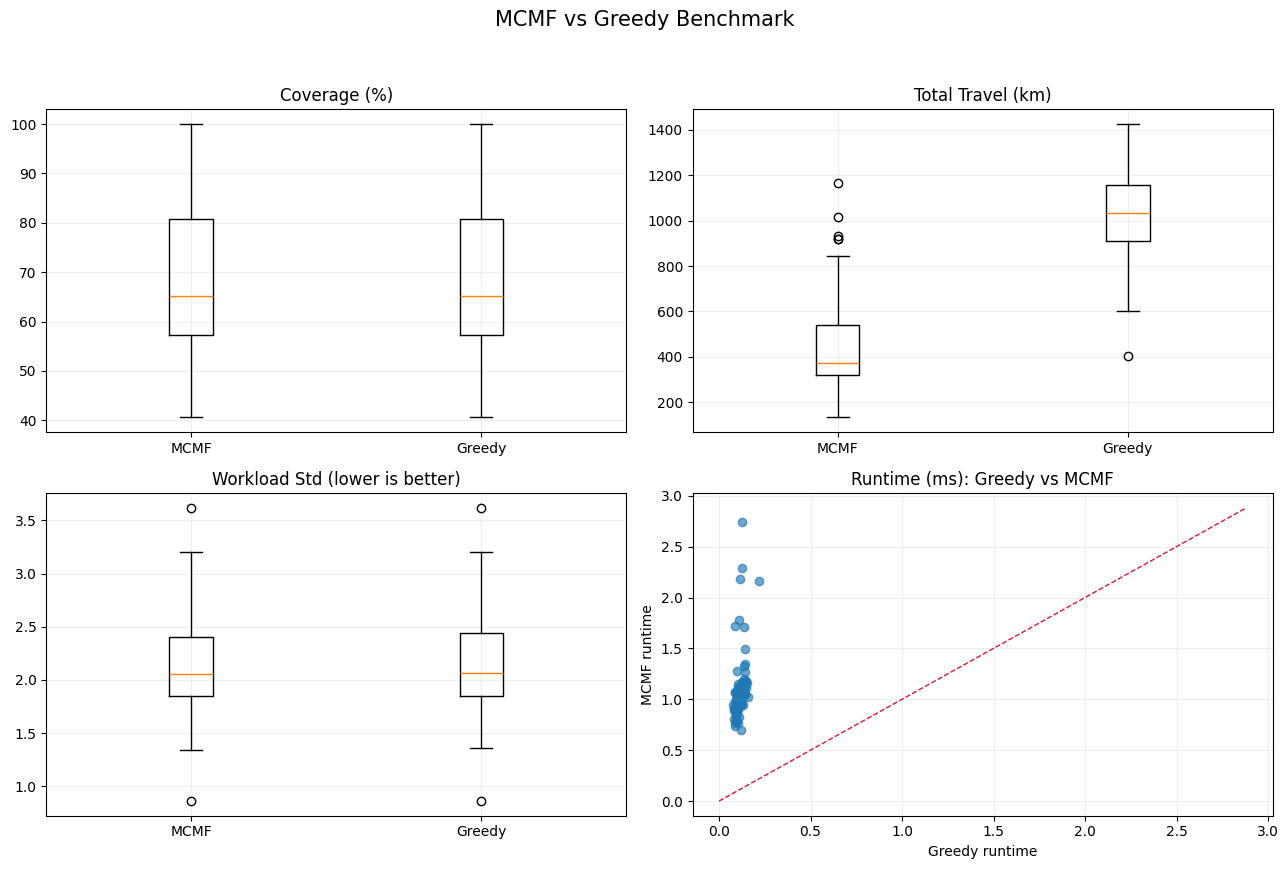

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].boxplot([df['mcmf_coverage'], df['greedy_coverage']], labels=['MCMF', 'Greedy'])
axes[0,0].set_title('Coverage (%)')
axes[0,0].grid(alpha=0.2)

axes[0,1].boxplot([df['mcmf_travel_km'], df['greedy_travel_km']], labels=['MCMF', 'Greedy'])
axes[0,1].set_title('Total Travel (km)')
axes[0,1].grid(alpha=0.2)

axes[1,0].boxplot([df['mcmf_workload_std'], df['greedy_workload_std']], labels=['MCMF', 'Greedy'])
axes[1,0].set_title('Workload Std (lower is better)')
axes[1,0].grid(alpha=0.2)

axes[1,1].scatter(df['greedy_runtime_ms'], df['mcmf_runtime_ms'], alpha=0.65)
mx = max(df['greedy_runtime_ms'].max(), df['mcmf_runtime_ms'].max()) * 1.05
axes[1,1].plot([0, mx], [0, mx], '--', color='crimson', linewidth=1)
axes[1,1].set_title('Runtime (ms): Greedy vs MCMF')
axes[1,1].set_xlabel('Greedy runtime')
axes[1,1].set_ylabel('MCMF runtime')
axes[1,1].grid(alpha=0.2)

fig.suptitle('MCMF vs Greedy Benchmark', fontsize=15)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()
